# TransformerQEC: Transformer Decoder & Training

Define and train a transformer-based neural decoder for surface code quantum error correction using JAX / Flax.

**Architecture:** Pre-norm transformer encoder with CLS-token classification and physical error rate conditioning (analogous to timestep conditioning in diffusion models).

In [12]:
!pip install -q "stim>=1.14" pymatching flax optax

In [13]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.training.train_state import TrainState
import optax
import numpy as np
import stim
import matplotlib.pyplot as plt
import pickle
import os
import time

print(f'JAX backend: {jax.default_backend()}')
print(f'JAX devices: {jax.devices()}')

JAX backend: tpu
JAX devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


## Data Generation

In [14]:
def make_circuit(d, p, rounds=None):
    if rounds is None:
        rounds = d
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
    )


def sample_syndromes(circuit, num_shots):
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return det.astype(np.float32), obs[:, 0].astype(np.int64)


def get_detector_coords(d, rounds=None):
    """Extract and normalize detector (x, y, round) coordinates.

    Returns: np.ndarray of shape (num_detectors, 3), float32, values in [0, 1].
    """
    circuit = make_circuit(d, p=0.01, rounds=rounds)  # p doesn't affect coords
    raw = circuit.get_detector_coordinates()
    num_det = circuit.num_detectors
    coords = np.zeros((num_det, 3), dtype=np.float32)
    for det_idx, c in raw.items():
        coords[det_idx] = c[:3]
    # Normalize each axis independently to [0, 1]
    for axis in range(3):
        lo, hi = coords[:, axis].min(), coords[:, axis].max()
        if hi > lo:
            coords[:, axis] = (coords[:, axis] - lo) / (hi - lo)
    return coords


def generate_dataset(d, p_values, shots_per_p):
    """Generate mixed-noise-rate dataset for a given code distance."""
    all_syn, all_lab, all_p = [], [], []
    for p in p_values:
        syn, lab = sample_syndromes(make_circuit(d, p), shots_per_p)
        all_syn.append(syn)
        all_lab.append(lab)
        all_p.append(np.full(shots_per_p, p, dtype=np.float32))
    coords = get_detector_coords(d)
    return (np.concatenate(all_syn), np.concatenate(all_lab),
            np.concatenate(all_p), coords)

## Model Architecture

Pre-norm transformer encoder with:
- **Token embedding:** each binary detection event $\rightarrow$ $d_{\text{model}}$-dim vector
- **3D positional encoding:** detector (x, y, round) coordinates projected via learned MLP, preserving spatial structure across code distances
- **CLS token:** aggregates global context for classification
- **Error rate conditioning:** physical error rate $p$ broadcast-added to all tokens
- **Gradient checkpointing (`nn.remat`):** recomputes block activations during backprop instead of storing all layers â€” reduces peak VRAM from $O(\text{layers})$ to $O(1)$ in attention activations, critical for $d=7$ ($L=337$) on T4

In [15]:
# Positional encoding:
#   "default" = additive MLP projecting [x,y,t] to d_model (absolute positions)
#   "rope"    = 2.5D Rotary Position Embedding: 2D RoPE on [x,y] + 1D RoPE on [t]
#              with 3:1 spatial:temporal dim ratio.  Encodes *relative* positions
#              only (translational invariance).  No additive pos embedding.
POS_ENCODING = "rope"

In [16]:
# ---------------------------------------------------------------------------
# 2.5D Rotary Position Embedding (RoPE) for QEC space-time coordinates
# ---------------------------------------------------------------------------
# Encodes [x,y] jointly via 2D RoPE and [t] via 1D RoPE into separate
# subspaces of each attention head.  After the standard Q @ K^T dot
# product, the score decomposes as:
#
#   Attention(i,j) ~ Q_{xy,i} . K_{xy,j}  +  Q_{t,i} . K_{t,j}
#
# because the spatial and temporal dimension chunks are orthogonal.
# Each chunk uses RoPE's rotation, so the score depends only on the
# *relative* displacement (dx, dy, dt) â€” translational invariance.
# ---------------------------------------------------------------------------

def _round_even(n):
    """Round to nearest even integer (RoPE needs dimension pairs)."""
    return int(2 * round(n / 2))


def build_rope_2_5d(coords, head_dim, seq_len,
                    spatial_ratio=3, temporal_ratio=1,
                    base_spatial=10000.0, base_temporal=10000.0):
    """Build cos/sin tables for 2.5D RoPE from [x,y,t] coordinates.

    The head dimensions are split into a spatial chunk (2D RoPE on x,y)
    and a temporal chunk (1D RoPE on t) according to the given ratio.

    Args:
        coords:      (L, 3) normalized detector coords [x, y, round].
        head_dim:    int, per-head dimension (must be even).
        seq_len:     int, used to scale [0,1]-normalized coords back to
                     integer-like magnitudes for the frequency spectrum.
        spatial_ratio:  int, relative weight for spatial dims (default 3).
        temporal_ratio: int, relative weight for temporal dims (default 1).
        base_spatial:   float, RoPE frequency base for [x,y] (default 10000).
        base_temporal:  float, RoPE frequency base for [t] (default 10000).

    Returns:
        (rope_cos, rope_sin) each of shape (L, head_dim//2).
    """
    total = spatial_ratio + temporal_ratio
    n_pairs = head_dim // 2  # total rotation-pair count

    # --- dynamic split, forced to even dim counts ---
    n_spatial_dims = _round_even(head_dim * spatial_ratio / total)
    n_spatial_dims = max(2, min(n_spatial_dims, head_dim - 2))  # at least 1 pair each
    n_temporal_dims = head_dim - n_spatial_dims

    n_spatial_pairs = n_spatial_dims // 2
    n_temporal_pairs = n_temporal_dims // 2

    # --- scale coords from [0,1] to integer-like range ---
    x_pos = coords[:, 0] * seq_len   # (L,)
    y_pos = coords[:, 1] * seq_len   # (L,)
    t_pos = coords[:, 2] * seq_len   # (L,)

    # =================================================================
    # Spatial chunk â€” 2D RoPE interleaving x and y
    # =================================================================
    # Allocate half the spatial pairs to x, half to y.  For each axis
    # we compute independent inverse-frequency bands, then interleave
    # the (x, y) angles so nearby spatial pairs encode the two axes at
    # the same frequency scale.  This joint encoding couples (x,y)
    # within the spatial subspace.
    n_x_pairs = n_spatial_pairs // 2
    n_y_pairs = n_spatial_pairs - n_x_pairs  # may be +1 if odd

    # Inverse-frequency bands: theta_i = 1 / base^(2i / n_spatial_dims)
    # Each axis gets its own progression so the frequency spectrum
    # covers the full range independently.
    freq_x = 1.0 / (base_spatial ** (2.0 * jnp.arange(n_x_pairs) / n_spatial_dims))
    freq_y = 1.0 / (base_spatial ** (2.0 * jnp.arange(n_y_pairs) / n_spatial_dims))

    # Outer products: position * frequency -> rotation angles
    angles_x = x_pos[:, None] * freq_x[None, :]   # (L, n_x_pairs)
    angles_y = y_pos[:, None] * freq_y[None, :]   # (L, n_y_pairs)

    # Vectorized interleave: stack + reshape replaces O(n) slice ops with 1 XLA op.
    min_pairs = min(n_x_pairs, n_y_pairs)
    paired = jnp.stack([angles_x[:, :min_pairs],
                        angles_y[:, :min_pairs]], axis=-1)        # (L, min_pairs, 2)
    interleaved = paired.reshape(angles_x.shape[0], min_pairs * 2)  # (L, min_pairs*2)
    # Append any remaining from the longer axis (at most 1 extra pair)
    parts = [interleaved]
    if n_x_pairs > min_pairs:
        parts.append(angles_x[:, min_pairs:])
    if n_y_pairs > min_pairs:
        parts.append(angles_y[:, min_pairs:])
    angles_spatial = jnp.concatenate(parts, axis=-1) if len(parts) > 1 else interleaved

    # =================================================================
    # Temporal chunk â€” standard 1D RoPE on t
    # =================================================================
    freq_t = 1.0 / (base_temporal ** (2.0 * jnp.arange(n_temporal_pairs) / n_temporal_dims))
    angles_temporal = t_pos[:, None] * freq_t[None, :]  # (L, n_temporal_pairs)

    # =================================================================
    # Concatenate spatial + temporal angles -> full (L, n_pairs) table
    # =================================================================
    angles = jnp.concatenate([angles_spatial, angles_temporal], axis=-1)
    return jnp.cos(angles), jnp.sin(angles)


def apply_rope(x, rope_cos, rope_sin):
    """Apply rotary embedding to the last dimension of x.

    Uses the half-split layout (LLaMA-style):
      x = [x_first_half | x_second_half]
    Each corresponding element pair (x_first[i], x_second[i]) is rotated
    by the angle at position i:
      out_first[i]  =  x_first[i] * cos[i]  -  x_second[i] * sin[i]
      out_second[i] =  x_first[i] * sin[i]  +  x_second[i] * cos[i]

    This is mathematically equivalent to the complex-number formulation
    but avoids complex dtypes for XLA compatibility.

    Args:
        x:        (..., head_dim)  â€” Q or K tensor.
        rope_cos: (..., head_dim//2) â€” cosine table (broadcastable).
        rope_sin: (..., head_dim//2) â€” sine table (broadcastable).

    Returns:
        Rotated tensor, same shape as x.
    """
    half = x.shape[-1] // 2
    x1 = x[..., :half]   # first half of dims
    x2 = x[..., half:]   # second half of dims
    out1 = x1 * rope_cos - x2 * rope_sin
    out2 = x1 * rope_sin + x2 * rope_cos
    return jnp.concatenate([out1, out2], axis=-1)


# ---------------------------------------------------------------------------
# Transformer blocks
# ---------------------------------------------------------------------------

class TransformerBlock(nn.Module):
    d_model: int
    num_heads: int
    ffn_dim: int
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, x):
        # Pre-norm multi-head self-attention
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads, dtype=self.dtype)(y, y)
        x = x + y
        # Pre-norm feed-forward
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.Dense(self.ffn_dim, dtype=self.dtype)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model, dtype=self.dtype)(y)
        return x + y


class TransformerBlockWithRoPE(nn.Module):
    """Pre-norm transformer block with manual attention for RoPE injection.

    RoPE must be applied to Q and K *after* linear projection but
    *before* the dot product.  Flax's MultiHeadDotProductAttention does
    not expose this hook point, so we project Q/K/V manually via
    DenseGeneral and compute scaled dot-product attention inline.
    """
    d_model: int
    num_heads: int
    ffn_dim: int
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, x, rope_cos, rope_sin):
        """
        Args:
            x:         (B, L, d_model)
            rope_cos:  (L, head_dim//2)  â€” precomputed cos table
            rope_sin:  (L, head_dim//2)  â€” precomputed sin table
        """
        head_dim = self.d_model // self.num_heads

        # --- Pre-norm self-attention with RoPE ---
        y = nn.LayerNorm(dtype=self.dtype)(x)

        # Project to multi-head Q, K, V: (B, L, num_heads, head_dim)
        q = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='query')(y)
        k = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='key')(y)
        v = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='value')(y)

        # Apply RoPE to Q and K.
        # rope tables: (L, half) -> broadcast to (1, L, 1, half) over B, H
        rc = rope_cos[None, :, None, :]   # (1, L, 1, half)
        rs = rope_sin[None, :, None, :]
        q = apply_rope(q, rc, rs)
        k = apply_rope(k, rc, rs)

        # Scaled dot-product attention
        # Transpose to (B, H, L, D) for batched matmul
        q = jnp.transpose(q, (0, 2, 1, 3))
        k = jnp.transpose(k, (0, 2, 1, 3))
        v = jnp.transpose(v, (0, 2, 1, 3))

        # Precision discipline: QK matmul in compute dtype (bf16 on TPU MXU),
        # upcast to f32 for softmax stability, then back to compute dtype
        # for V matmul — keeps both MXU matmuls in bf16.
        scale = jnp.sqrt(jnp.array(head_dim, dtype=jnp.float32))
        attn_weights = jnp.matmul(q, jnp.swapaxes(k, -2, -1))   # bf16 @ bf16 on MXU
        attn_weights = attn_weights.astype(jnp.float32) / scale   # f32 for softmax
        attn_weights = jax.nn.softmax(attn_weights, axis=-1)
        attn_weights = attn_weights.astype(self.dtype)             # back to compute dtype
        attn_out = jnp.matmul(attn_weights, v)    # bf16 @ bf16 on MXU

        # Back to (B, L, H, D) then project to d_model
        attn_out = jnp.transpose(attn_out, (0, 2, 1, 3))
        attn_out = nn.DenseGeneral(features=self.d_model,
                                   axis=(-2, -1), dtype=self.dtype, name='out')(attn_out)

        x = x + attn_out

        # --- Pre-norm feed-forward (identical to standard block) ---
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.Dense(self.ffn_dim, dtype=self.dtype)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model, dtype=self.dtype)(y)
        return x + y





# ---------------------------------------------------------------------------
# Main model
# ---------------------------------------------------------------------------

class TransformerQEC(nn.Module):
    d_model: int = 128
    num_heads: int = 4
    num_layers: int = 4
    ffn_dim: int = 1024
    num_classes: int = 2
    pos_encoding: str = POS_ENCODING  # "default" | "rope"
    rope_spatial_ratio: int = 3  # spatial:temporal dim ratio for RoPE
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, syndrome, p_error, coords):
        """
        Args:
            syndrome: (B, L) binary detection events
            p_error:  (B,) physical error rates
            coords:   (L, 3) normalized detector coordinates (x, y, round)
        """
        B, L = syndrome.shape
        head_dim = self.d_model // self.num_heads

        # Embed each binary detection event
        x = nn.Dense(self.d_model, dtype=self.dtype)(syndrome[..., None])  # (B, L, d_model)

        # --- Positional encoding ---
        if self.pos_encoding == "rope":
            # RoPE: no additive positional encoding on tokens.
            # Rotation tables are built here and passed into each block.
            pass  # positions handled below via rope tables
        else:
            # Default additive MLP: [x, y, t] -> d_model
            pos = nn.Dense(self.d_model, dtype=self.dtype)(coords)   # (L, d_model)
            pos = nn.gelu(pos)
            pos = nn.Dense(self.d_model, dtype=self.dtype)(pos)      # (L, d_model)
            x = x + pos[None, :, :]

        # Prepend learnable CLS token
        # Cast CLS from f32 param to compute dtype to prevent
        # silent upcast when concatenated with bf16 sequence
        cls = self.param('cls_token',
            nn.initializers.normal(stddev=0.02),
            (1, 1, self.d_model))
        cls = cls.astype(self.dtype)
        x = jnp.concatenate(
            [jnp.broadcast_to(cls, (B, 1, self.d_model)), x], axis=1)

        # Condition on physical error rate
        p_cond = nn.Dense(self.d_model, dtype=self.dtype)(p_error[:, None])
        p_cond = nn.gelu(p_cond)
        p_cond = nn.Dense(self.d_model, dtype=self.dtype)(p_cond)
        x = x + p_cond[:, None, :]  # broadcast to all tokens

        # --- Transformer encoder stack ---
        if self.pos_encoding == "rope":
            # Build 2.5D RoPE tables from detector coordinates
            rope_cos, rope_sin = build_rope_2_5d(
                coords, head_dim, L,
                spatial_ratio=self.rope_spatial_ratio, temporal_ratio=1)
            # Cast from f32 (trig precision) to compute dtype for MXU
            rope_cos = rope_cos.astype(self.dtype)
            rope_sin = rope_sin.astype(self.dtype)
            # Prepend identity rotation for CLS token (no physical position):
            # cos=1, sin=0 means Q/K pass through unrotated â€” CLS attends
            # everywhere without positional bias.
            cls_cos = jnp.ones((1, head_dim // 2), dtype=self.dtype)
            cls_sin = jnp.zeros((1, head_dim // 2), dtype=self.dtype)
            rope_cos = jnp.concatenate([cls_cos, rope_cos], axis=0)  # (L+1, half)
            rope_sin = jnp.concatenate([cls_sin, rope_sin], axis=0)

            for _ in range(self.num_layers):
                x = TransformerBlockWithRoPE(
                    self.d_model, self.num_heads, self.ffn_dim,
                    dtype=self.dtype)(x, rope_cos, rope_sin)
        else:
            for _ in range(self.num_layers):
                x = TransformerBlock(
                    self.d_model, self.num_heads, self.ffn_dim,
                    dtype=self.dtype)(x)

        # Classification head: float32 for numerical stability
        h = nn.LayerNorm()(x[:, 0].astype(jnp.float32))
        h = nn.Dense(self.d_model)(h)
        h = nn.gelu(h)
        return nn.Dense(self.num_classes)(h)

## Training Setup

In [17]:
def focal_loss(logits, labels, num_classes=2, gamma=2.0, alpha=0.75):
    """Focal loss for class-imbalanced binary classification.

    Logical errors are ~0.02-0.2% of samples at low physical error rates,
    so standard cross-entropy gradient is dominated by the overwhelming
    majority of easy "no flip" examples. Focal loss down-weights
    well-classified examples by (1 - p_t)^gamma, letting the model
    focus on hard/rare positive cases. alpha weights the rare positive
    class more heavily.
    """
    probs = jax.nn.softmax(logits)
    one_hot = jax.nn.one_hot(labels, num_classes)
    # p_t: probability assigned to the correct class
    p_t = (probs * one_hot).sum(-1)
    # alpha_t: alpha for positive (flip) examples, (1-alpha) for negative
    alpha_t = alpha * labels + (1.0 - alpha) * (1 - labels)
    focal_weight = (1.0 - p_t) ** gamma
    loss = -alpha_t * focal_weight * jnp.log(p_t + 1e-8)
    return loss.mean()


def create_train_state(key, model, seq_len, coords, num_steps, warmup_steps=2000, peak_lr=1e-4):
    dummy_syn = jnp.zeros((1, seq_len))
    dummy_p = jnp.zeros((1,))
    params = model.init(key, dummy_syn, dummy_p, coords)["params"]

    # Clamp warmup so cosine decay portion is always positive
    warmup_steps = min(warmup_steps, num_steps // 5)

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr,
        warmup_steps=warmup_steps,
        decay_steps=num_steps, end_value=5*1e-7)

    # Muon optimizer: Newton-Schulz preconditioned SGD on 2D params (Dense
    # kernels), AdamW on 1D params (biases, LayerNorm scales).
    # adam_learning_rate = 20% of peak for the AdamW fallback path.
    muon_adam_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr * 0.2,
        warmup_steps=warmup_steps,
        decay_steps=num_steps, end_value=1e-6 * 0.2)
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.contrib.muon(
            learning_rate=schedule,
            adam_learning_rate=muon_adam_schedule,
            weight_decay=0.1))
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


def make_epoch_fns(model, coords_d):
    """Build fully-JIT'd epoch functions using jax.lax.scan.

    Train function receives data arrays as JIT arguments (not closed-over
    constants) so they are traced as abstract inputs instead of being
    captured as multi-GB constants during XLA lowering.

    Eval function takes pre-batched data directly (no shuffling needed).
    """

    @jax.jit
    def train_epoch(state, index_batches, train_syn_d, train_lab_d, train_pe_d):
        """Entire epoch as one compiled XLA while-loop.

        index_batches: int32 array of shape (n_batches, batch_size).
        train_syn_d, train_lab_d, train_pe_d: device-resident dataset
            arrays passed as JIT arguments to avoid captured-constant overhead.
        """
        def _train_body(state, batch_indices):
            syn = train_syn_d[batch_indices]
            lab = train_lab_d[batch_indices]
            pe  = train_pe_d[batch_indices]
            def loss_fn(params):
                logits = model.apply({"params": params}, syn, pe, coords_d)
                return focal_loss(logits, lab), logits
            (loss, logits), grads = jax.value_and_grad(
                loss_fn, has_aux=True)(state.params)
            state = state.apply_gradients(grads=grads)
            acc = (logits.argmax(-1) == lab).mean()
            return state, (loss, acc)

        state, (losses, accs) = jax.lax.scan(
            _train_body, state, index_batches)
        return state, losses.mean(), accs.mean()

    @jax.jit
    def eval_epoch(params, batches):
        """Validation sweep as one compiled XLA while-loop."""
        def body(metrics, batch):
            loss_sum, acc_sum = metrics
            syn, lab, pe = batch
            logits = model.apply({"params": params}, syn, pe, coords_d)
            loss = focal_loss(logits, lab)
            acc = (logits.argmax(-1) == lab).mean()
            return (loss_sum + loss, acc_sum + acc), None
        n = batches[0].shape[0]  # static during tracing
        (total_loss, total_acc), _ = jax.lax.scan(
            body, (jnp.float32(0.0), jnp.float32(0.0)), batches)
        return total_loss / n, total_acc / n
    return train_epoch, eval_epoch

## Generate Data & Initialize Model

In [18]:
# --- Configuration ---
DISTANCE = 3
NUM_P = 20
TOTAL_SAMPLES = 6_000_000
P_TRAIN = np.geomspace(0.002, 0.017, NUM_P).tolist()  # log-spaced physical error rates
SHOTS_PER_P = TOTAL_SAMPLES // NUM_P
NUM_EPOCHS = 13
SEED = 42
# Generate training and validation data
print(f'Error rates ({NUM_P} geomspace): {[f"{p:.4f}" for p in P_TRAIN]}')
print('Generating training data...')
train_syn, train_lab, train_p, coords = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P)
print('Generating validation data...')
val_syn, val_lab, val_p, _ = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P // 20)
print(f'Train: {train_syn.shape[0]:,} samples, '
      f'seq_len={train_syn.shape[1]}, '
      f'error_rate={train_lab.mean():.3f}')
print(f'Val:   {val_syn.shape[0]:,} samples')
print(f'Coords: {coords.shape} (detector positions, normalized)')

Error rates (20 geomspace): ['0.0020', '0.0022', '0.0025', '0.0028', '0.0031', '0.0035', '0.0039', '0.0044', '0.0049', '0.0055', '0.0062', '0.0069', '0.0077', '0.0086', '0.0097', '0.0108', '0.0121', '0.0136', '0.0152', '0.0170']
Generating training data...
Generating validation data...
Train: 6,000,000 samples, seq_len=24, error_rate=0.059
Val:   300,000 samples
Coords: (24, 3) (detector positions, normalized)


In [19]:
# Initialize model and optimizer
seq_len = train_syn.shape[1]
model = TransformerQEC(pos_encoding=POS_ENCODING, dtype=jnp.bfloat16)
coords_d = jax.device_put(coords) # Transfer coords to device once
BATCH_SIZE = 1024
steps_per_epoch = len(train_syn) // BATCH_SIZE
num_steps = steps_per_epoch * NUM_EPOCHS
# Warmup = 2 epochs: enough to ramp LR even with large-batch low step counts
warmup_steps = steps_per_epoch * 2
key = jax.random.PRNGKey(SEED)
state = create_train_state(key, model, seq_len, coords_d, num_steps,
                           warmup_steps=warmup_steps)
param_count = sum(p.size for p in jax.tree_util.tree_leaves(state.params))
print(f'Parameters:   {param_count:,}')
print(f'Pos encoding: {POS_ENCODING}')
print(f'Sequence len: {seq_len}')
print(f'Batch size:   {BATCH_SIZE}')
print(f'Steps/epoch:  {steps_per_epoch}')
print(f'Warmup steps: {warmup_steps}')
print(f'Total steps:  {num_steps:,}')

Parameters:   1,353,602
Pos encoding: rope
Sequence len: 24
Batch size:   1024
Steps/epoch:  5859
Warmup steps: 11718
Total steps:  76,167


## Training Loop

In [20]:
import pickle, os
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/My Drive/TransformerQEC/results'
os.makedirs(save_dir, exist_ok=True)

best_val_loss = float('inf')
best_params = None
best_epoch = 0
best_val_acc = 0.0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
# Trim to exact batch multiples
n_train = (len(train_syn) // BATCH_SIZE) * BATCH_SIZE
n_val   = (len(val_syn) // BATCH_SIZE) * BATCH_SIZE
n_train_batches = n_train // BATCH_SIZE
n_val_batches   = n_val // BATCH_SIZE
# ---- Transfer ALL data to device ONCE ----
# p_error cast to bfloat16: matches model compute dtype, avoids
# silent f32 upcast when Dense(dtype=bf16) receives f32 input.
train_syn_d = jax.device_put(train_syn[:n_train])
train_lab_d = jax.device_put(train_lab[:n_train])
train_p_d   = jax.device_put(jnp.asarray(train_p[:n_train], dtype=jnp.bfloat16))
# Pre-batch validation data for scan: (n_val_batches, BATCH_SIZE, ...)
val_batches = (
    jax.device_put(val_syn[:n_val]).reshape(n_val_batches, BATCH_SIZE, seq_len),
    jax.device_put(val_lab[:n_val]).reshape(n_val_batches, BATCH_SIZE),
    jax.device_put(jnp.asarray(val_p[:n_val], dtype=jnp.bfloat16)).reshape(n_val_batches, BATCH_SIZE),
)
# Build epoch functions — train fn closes over device data arrays,
# gathers per-batch by index inside the scan body (no full-dataset copy).
# Build epoch functions — data arrays are now passed as JIT arguments
# (not closed over) to avoid capturing ~2 GB of constants during lowering.
train_epoch, eval_epoch = make_epoch_fns(model, coords_d)
print(f'{n_train_batches} train batches, {n_val_batches} val batches per epoch')
# ---- Training loop ----
train_key = jax.random.PRNGKey(SEED + 1)
prev_safety_path = None
t0 = time.time()
for epoch in range(NUM_EPOCHS):
    # Shuffle on-device via JAX PRNG (zero host->device data transfer)
    train_key, subkey = jax.random.split(train_key)
    perm = jax.random.permutation(subkey, n_train)
    index_batches = perm.reshape(n_train_batches, BATCH_SIZE)
    # ONE call — entire epoch is a single compiled XLA while-loop.
    # Optimizer LR schedule advances correctly via state.step in the carry.
    state, train_loss, train_acc = train_epoch(
        state, index_batches, train_syn_d, train_lab_d, train_p_d)
    val_loss, val_acc = eval_epoch(state.params, val_batches)
    # Block until device computation finishes before reading wall-clock.
    # JAX dispatches asynchronously — without this, elapsed time measures
    # only dispatch overhead, not actual TPU execution.
    val_acc.block_until_ready()
    elapsed = time.time() - t0
    # Host sync: float() implicitly calls block_until_ready() on each scalar
    train_losses.append(float(train_loss))
    train_accs.append(float(train_acc))
    val_losses.append(float(val_loss))
    val_accs.append(float(val_acc))
    tag = ' [incl. JIT compilation]' if epoch == 0 else ''
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.4f} | '
          f'val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.4f} | '
          f'{elapsed:.1f}s{tag}')

    # ---- Best-model tracking ----
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_val_acc = val_accs[-1]
        best_epoch = epoch + 1
        best_params = jax.tree.map(lambda x: x.copy(), state.params)
        print(f'  \u2191 New best (epoch {best_epoch}, val_loss={best_val_loss:.6f}, val_acc={best_val_acc:.4f})')

    # ---- Safety checkpoint every 3 epochs ----
    if (epoch + 1) % 3 == 0:
        safety_ckpt = {
            'params': jax.device_get(state.params),
            'config': {
                'distance': DISTANCE,
                'seq_len': seq_len,
                'd_model': model.d_model,
                'num_heads': model.num_heads,
                'num_layers': model.num_layers,
                'ffn_dim': model.ffn_dim,
                'pos_encoding': model.pos_encoding,
            },
            'coords': coords,
        }
        safety_path = f'{save_dir}/safety_d{DISTANCE}_epoch{epoch+1}.pkl'
        with open(safety_path, 'wb') as f:
            pickle.dump(safety_ckpt, f)
        if prev_safety_path and os.path.exists(prev_safety_path):
            os.remove(prev_safety_path)
        prev_safety_path = safety_path
        print(f'  Safety checkpoint saved ({os.path.getsize(safety_path):,} bytes)')

# Free training device arrays
del train_syn_d, train_lab_d, train_p_d

# ---- Save best model to Drive ----
best_checkpoint = {
    'params': jax.device_get(best_params),
    'config': {
        'distance': DISTANCE,
        'seq_len': seq_len,
        'd_model': model.d_model,
        'num_heads': model.num_heads,
        'num_layers': model.num_layers,
        'ffn_dim': model.ffn_dim,
        'pos_encoding': model.pos_encoding,
    },
    'coords': coords,
    'epoch': best_epoch,
    'val_loss': float(best_val_loss),
    'val_acc': float(best_val_acc),
}
best_path = f'{save_dir}/best_d{DISTANCE}_checkpoint.pkl'
with open(best_path, 'wb') as f:
    pickle.dump(best_checkpoint, f)
print(f'\nBest model (epoch {best_epoch}) saved to {best_path} ({os.path.getsize(best_path):,} bytes)')

5859 train batches, 292 val batches per epoch
Epoch  1/13 | train loss=0.0142 acc=0.9225 | val loss=0.0033 acc=0.9887 | 135.2s [incl. JIT compilation]
  ↑ New best (epoch 1, val_loss=0.003309, val_acc=0.9887)
Epoch  2/13 | train loss=0.0028 acc=0.9914 | val loss=0.0025 acc=0.9933 | 170.9s
  ↑ New best (epoch 2, val_loss=0.002491, val_acc=0.9933)
Epoch  3/13 | train loss=0.0024 acc=0.9934 | val loss=0.0024 acc=0.9934 | 206.6s
  ↑ New best (epoch 3, val_loss=0.002432, val_acc=0.9934)
  Safety checkpoint saved (5,418,665 bytes)
Epoch  4/13 | train loss=0.0023 acc=0.9939 | val loss=0.0023 acc=0.9939 | 242.3s
  ↑ New best (epoch 4, val_loss=0.002296, val_acc=0.9939)
Epoch  5/13 | train loss=0.0023 acc=0.9941 | val loss=0.0023 acc=0.9939 | 278.0s
Epoch  6/13 | train loss=0.0022 acc=0.9942 | val loss=0.0023 acc=0.9947 | 313.7s
  ↑ New best (epoch 6, val_loss=0.002261, val_acc=0.9947)
  Safety checkpoint saved (5,418,665 bytes)
Epoch  7/13 | train loss=0.0022 acc=0.9943 | val loss=0.0022 acc=0

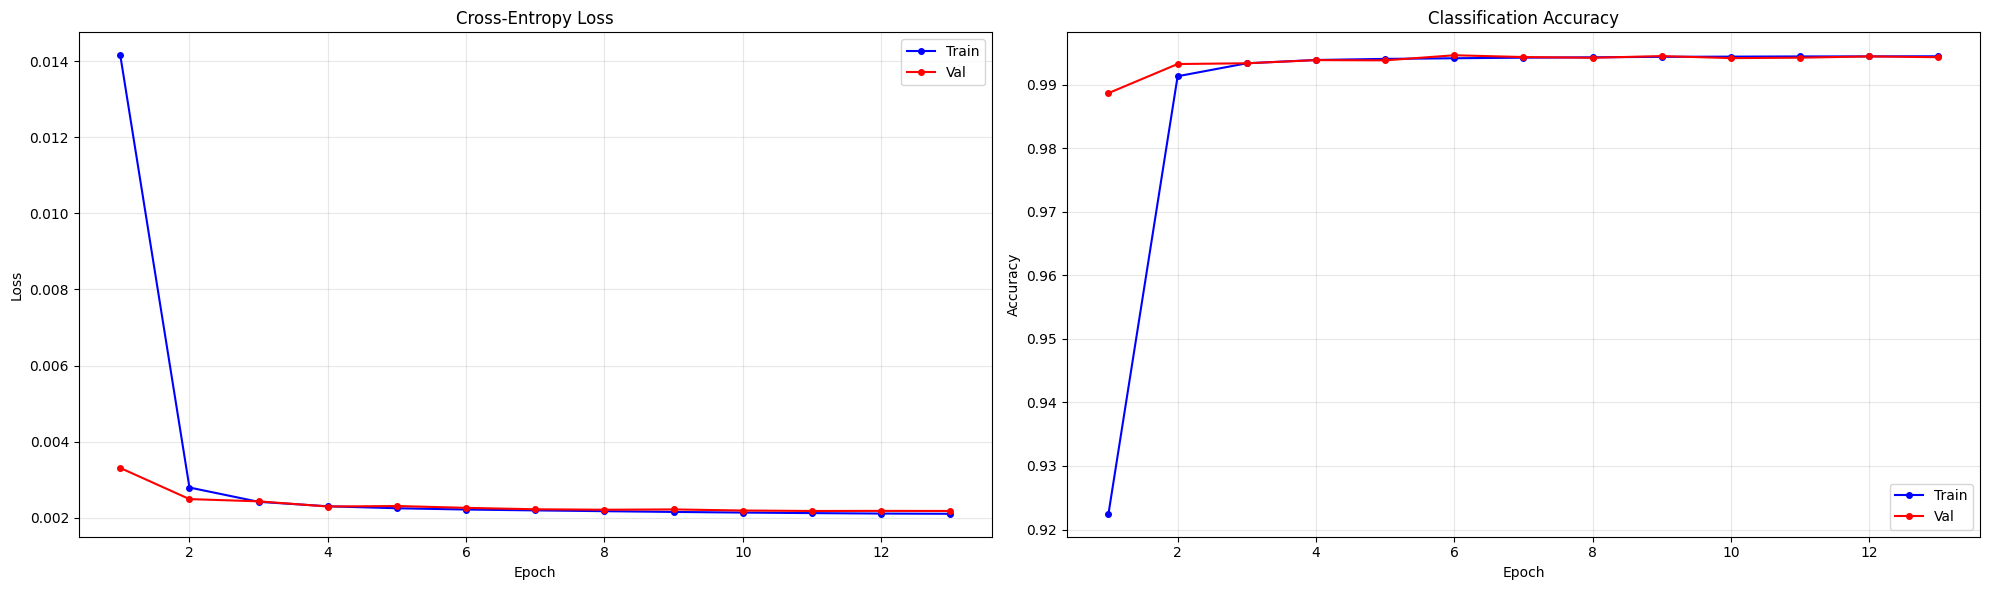

In [22]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val', markersize=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train', markersize=4)
ax2.plot(epochs, val_accs, 'r-o', label='Val', markersize=4)
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Classification Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Next Steps

- Train for d=3 and d=7 by changing `DISTANCE` above and re-running.
- Proceed to **03_evaluation.ipynb** for MWPM comparison and threshold analysis.
- Experiment with model size, learning rate, or training noise rates.